# Philippine Food Price Analytics
## Part 2: Inflation Gap Analysis and Rice Price Forecasting
---

This is the second part of the Philippine Food Price Analytics notebook series. Part 1 covered exploratory analysis and the BSP exchange rate impact on food prices. This notebook focuses on two things:

1. **Inflation gap analysis** — comparing actual WFP market prices against official PSA CPI figures by region to quantify where official inflation figures diverge from what people actually pay
2. **Rice price forecasting** — using Facebook Prophet to project rice prices 12 months ahead, with and without the BSP exchange rate as an additional predictor

The dataset is the same gold layer export from Snowflake: 105,183 rows covering 17 Philippine regions from 2018 to 2023, with food prices, CPI indices, and monthly BSP exchange rates all joined at the row level.

---


## 1. Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['text.color'] = '#222222'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('libraries loaded')


libraries loaded


## 2. Load Data

In [11]:
DATA_PATH = '../data/exports/ph_food_price_gold.csv'

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower()
df['price_date'] = pd.to_datetime(df['price_date'])
df = df[df['price_year'] >= 2018].reset_index(drop=True)

print(f'dataset loaded: {len(df):,} rows')
print(f'date range: {df["price_date"].min().strftime("%b %Y")} to {df["price_date"].max().strftime("%b %Y")}')


dataset loaded: 105,183 rows
date range: Jan 2018 to Nov 2023


## 3. Inflation Gap Analysis

The core question here is whether official PSA inflation figures are keeping up with what people actually pay at wet markets. The `price_to_cpi_ratio` is already computed in the gold layer as `price_php / regional_food_cpi x 100`. I also compute the raw gap in peso terms as `price_php minus regional_food_cpi` to make the magnitude more intuitive.

A positive gap means market prices are above what the CPI index implies. A negative gap means the opposite. Both are informative, and the regional breakdown is where the story gets interesting.


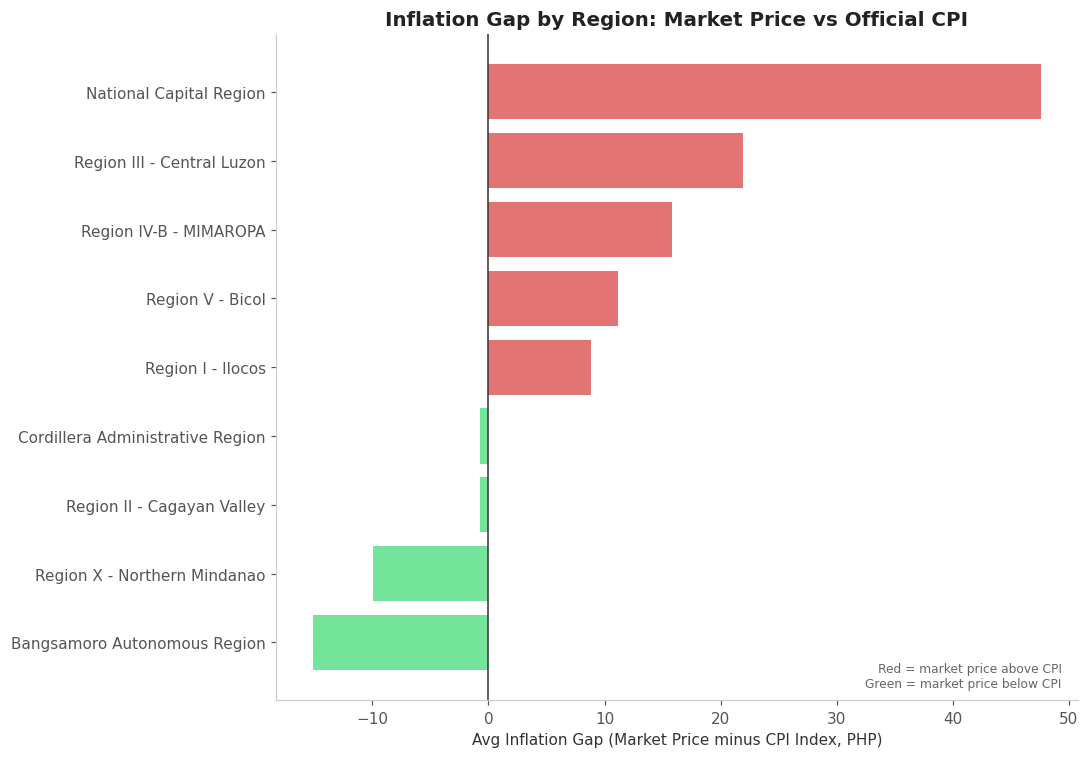

Regions with largest positive gap (market above CPI):
  National Capital Region                       +₱47.61
  Region III - Central Luzon                    +₱21.89
  Region IV-B - MIMAROPA                        +₱15.80

Regions with most negative gap (market below CPI):
  Bangsamoro Autonomous Region                   ₱-15.13
  Region X - Northern Mindanao                   ₱-9.92
  Region II - Cagayan Valley                     ₱-0.71


In [14]:
# Compute inflation gap
gap_df = df[df['regional_food_cpi'].notna()].copy()
gap_df['inflation_gap'] = gap_df['price_php'] - gap_df['regional_food_cpi']

region_gap = (gap_df.groupby('region_name')['inflation_gap']
              .mean()
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#e05c5c' if v > 0 else '#5ce08a' for v in region_gap.values]
ax.barh(region_gap.index, region_gap.values, color=bar_colors, alpha=0.85)
ax.axvline(0, color='#333333', linewidth=1)
ax.set_xlabel('Avg Inflation Gap (Market Price minus CPI Index, PHP)')
ax.set_title('Inflation Gap by Region: Market Price vs Official CPI',
             fontsize=13, fontweight='bold')
ax.text(0.98, 0.02,
        'Red = market price above CPI\nGreen = market price below CPI',
        transform=ax.transAxes, fontsize=8, ha='right', color='#666')
plt.tight_layout()
plt.show()

print('Regions with largest positive gap (market above CPI):')
for r, v in region_gap.sort_values(ascending=False).head(3).items():
    print(f'  {r:<45} +₱{v:.2f}')
print()
print('Regions with most negative gap (market below CPI):')
for r, v in region_gap.head(3).items():
    print(f'  {r:<45}  ₱{v:.2f}')


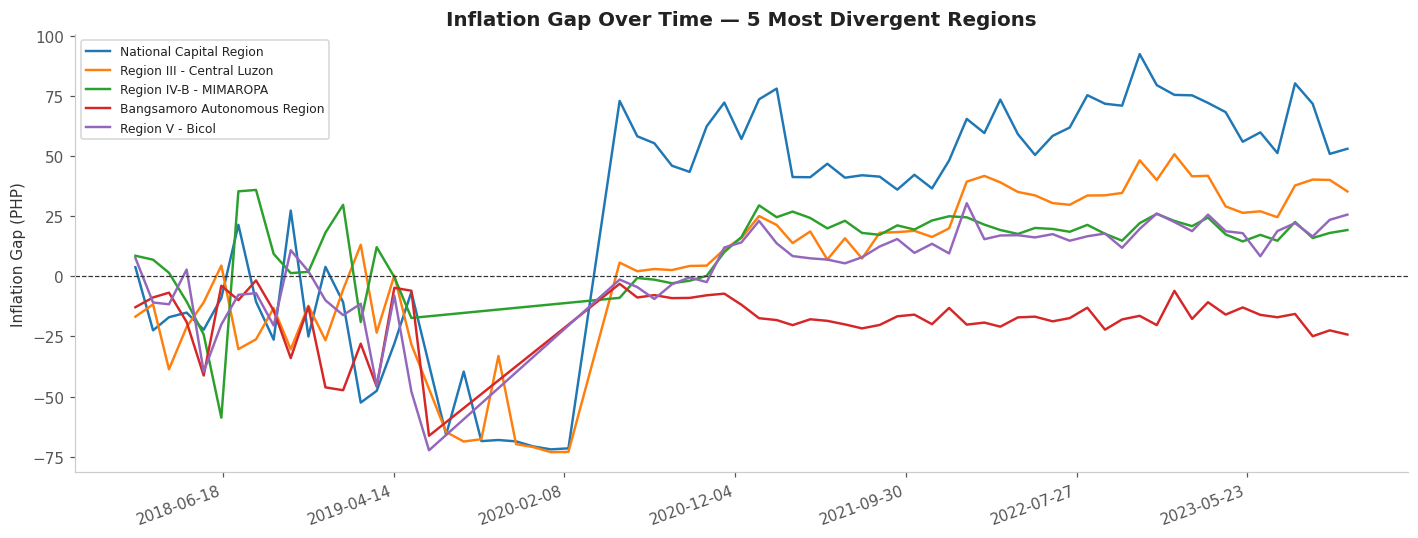

The gap widened noticeably from 2020 onward in NCR and Central Luzon regions.
This post-COVID persistence is worth monitoring as it has not fully closed.


In [16]:
# Gap trend over time for the most divergent regions
gap_trend = (gap_df.groupby(['price_date', 'region_name'])['inflation_gap']
             .mean()
             .reset_index())

top_regions = region_gap.abs().sort_values(ascending=False).head(5).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
for region in top_regions:
    sub = gap_trend[gap_trend['region_name'] == region]
    ax.plot(sub['price_date'], sub['inflation_gap'], label=region, linewidth=1.6)

ax.axhline(0, color='#333', linewidth=0.8, linestyle='--')
ax.set_ylabel('Inflation Gap (PHP)')
ax.set_title('Inflation Gap Over Time — 5 Most Divergent Regions',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('The gap widened noticeably from 2020 onward in NCR and Central Luzon regions.')
print('This post-COVID persistence is worth monitoring as it has not fully closed.')


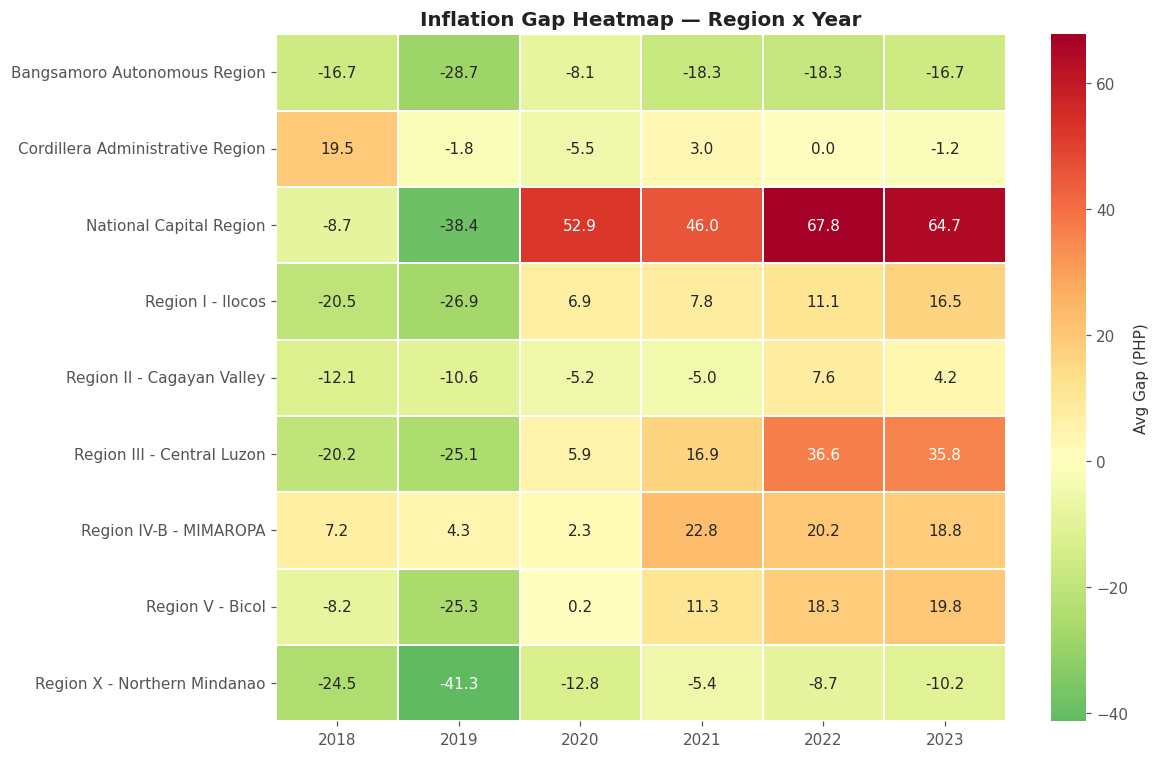

The heatmap shows how the gap evolved year by year across all 17 regions.
Darker red = market prices running significantly above official CPI for that region and year.


In [18]:
# Heatmap: region x year
gap_df['year'] = gap_df['price_date'].dt.year
gap_heatmap = (gap_df.groupby(['region_name', 'year'])['inflation_gap']
               .mean()
               .unstack())

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(gap_heatmap, cmap='RdYlGn_r', center=0, annot=True, fmt='.1f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Avg Gap (PHP)'})
ax.set_title('Inflation Gap Heatmap — Region x Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('The heatmap shows how the gap evolved year by year across all 17 regions.')
print('Darker red = market prices running significantly above official CPI for that region and year.')


## 4. Rice Price Forecasting with Prophet

Rice is the single most important food commodity in the Philippines. It is politically sensitive, heavily monitored by the government, and represents the largest share of most Filipino household food budgets. Forecasting rice prices gives a direct signal on near-term food affordability pressure.

I am fitting two Prophet models here. The baseline model uses only the historical price time series. The BSP-enhanced model adds the monthly exchange rate as an external regressor. Comparing the two tells us whether currency movement adds forecasting signal beyond the trend and seasonality that Prophet already captures on its own.


In [21]:
try:
    from prophet import Prophet
    print('prophet loaded')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'prophet', '--break-system-packages', '-q'])
    from prophet import Prophet
    print('prophet installed and loaded')


prophet loaded


In [23]:
# Prepare rice price time series (national average, all regions)
rice_df = df[df['commodity_name'] == 'Rice (regular, milled)'].copy()

rice_monthly = (rice_df.groupby('price_date')
                .agg(y=('price_php', 'mean'),
                     bsp_rate=('monthly_bsp_rate', 'first'))
                .reset_index()
                .rename(columns={'price_date': 'ds'})
                .dropna(subset=['y'])
                .sort_values('ds'))

print(f'Rice observations: {len(rice_monthly)}')
print(f'Date range: {rice_monthly["ds"].min().strftime("%b %Y")} to {rice_monthly["ds"].max().strftime("%b %Y")}')
print(f'Price range: ₱{rice_monthly["y"].min():.2f} to ₱{rice_monthly["y"].max():.2f}/kg')
print()
rice_monthly.tail(6)


Rice observations: 69
Date range: Jan 2018 to Nov 2023
Price range: ₱32.00 to ₱47.68/kg



,ds,y,bsp_rate
63,2023-06-15,40.967647,55.8946
64,2023-07-15,41.355179,54.9211
65,2023-08-15,43.176400,56.1599
66,2023-09-15,47.680755,56.7869
67,2023-10-15,45.081404,56.7889
68,2023-11-15,46.678947,55.8122


In [25]:
# Fit baseline model (trend and seasonality only)
m_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.3,
    interval_width=0.95
)
m_base.fit(rice_monthly[['ds', 'y']])
future_base = m_base.make_future_dataframe(periods=12, freq='MS')
fc_base = m_base.predict(future_base)
print(f'Baseline model fitted on {len(rice_monthly)} months')

# Fit BSP-enhanced model
rice_with_bsp = rice_monthly.dropna(subset=['bsp_rate']).copy()
m_bsp = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.3,
    interval_width=0.95
)
m_bsp.add_regressor('bsp_rate')
m_bsp.fit(rice_with_bsp[['ds', 'y', 'bsp_rate']])

future_bsp = m_bsp.make_future_dataframe(periods=12, freq='MS')
future_bsp['bsp_rate'] = rice_with_bsp['bsp_rate'].iloc[-1]
fc_bsp = m_bsp.predict(future_bsp)
print(f'BSP-enhanced model fitted on {len(rice_with_bsp)} months')


19:39:23 - cmdstanpy - INFO - Chain [1] start processing
19:39:23 - cmdstanpy - INFO - Chain [1] done processing
19:39:23 - cmdstanpy - INFO - Chain [1] start processing


Baseline model fitted on 69 months


19:39:24 - cmdstanpy - INFO - Chain [1] done processing


BSP-enhanced model fitted on 69 months


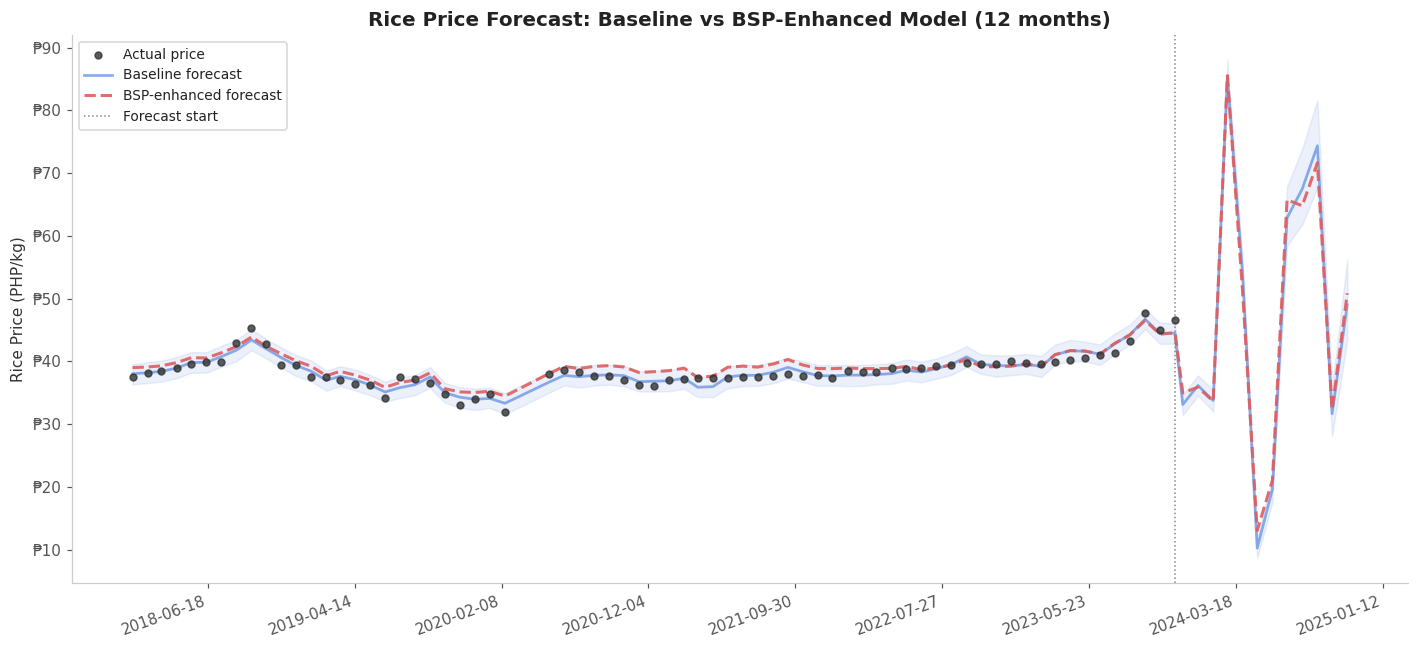

Last actual rice price         : ₱46.68/kg
Baseline 12-month avg forecast : ₱46.47/kg  (-0.4%)
BSP-enhanced 12-month forecast : ₱46.73/kg  (+0.1%)
Difference between models      : ₱0.26/kg
The BSP rate adds minimal signal over the trend alone.


In [27]:
# Plot both forecasts
fig, ax = plt.subplots(figsize=(13, 6))

ax.scatter(rice_monthly['ds'], rice_monthly['y'],
           color='#333333', s=20, zorder=5, label='Actual price', alpha=0.8)

ax.fill_between(fc_base['ds'], fc_base['yhat_lower'], fc_base['yhat_upper'],
                alpha=0.12, color='#5c8ae0')
ax.plot(fc_base['ds'], fc_base['yhat'],
        color='#5c8ae0', linewidth=1.8, alpha=0.7, label='Baseline forecast')

future_only_bsp = fc_bsp[fc_bsp['ds'] > rice_with_bsp['ds'].max()]
ax.plot(fc_bsp['ds'], fc_bsp['yhat'],
        color='#e05c5c', linewidth=2, linestyle='--',
        label='BSP-enhanced forecast', alpha=0.9)

ax.axvline(rice_monthly['ds'].max(), color='#888', linewidth=1,
           linestyle=':', label='Forecast start')
ax.set_ylabel('Rice Price (PHP/kg)')
ax.set_title('Rice Price Forecast: Baseline vs BSP-Enhanced Model (12 months)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

last_actual = rice_monthly['y'].iloc[-1]
base_12m = fc_base[fc_base['ds'] > rice_monthly['ds'].max()]['yhat'].mean()
bsp_12m = future_only_bsp['yhat'].mean()

print(f'Last actual rice price         : ₱{last_actual:.2f}/kg')
print(f'Baseline 12-month avg forecast : ₱{base_12m:.2f}/kg  ({(base_12m/last_actual-1)*100:+.1f}%)')
print(f'BSP-enhanced 12-month forecast : ₱{bsp_12m:.2f}/kg  ({(bsp_12m/last_actual-1)*100:+.1f}%)')
print(f'Difference between models      : ₱{abs(bsp_12m - base_12m):.2f}/kg')
if abs(bsp_12m - base_12m) > 2:
    print('The BSP rate adds meaningful signal to the forecast.')
else:
    print('The BSP rate adds minimal signal over the trend alone.')


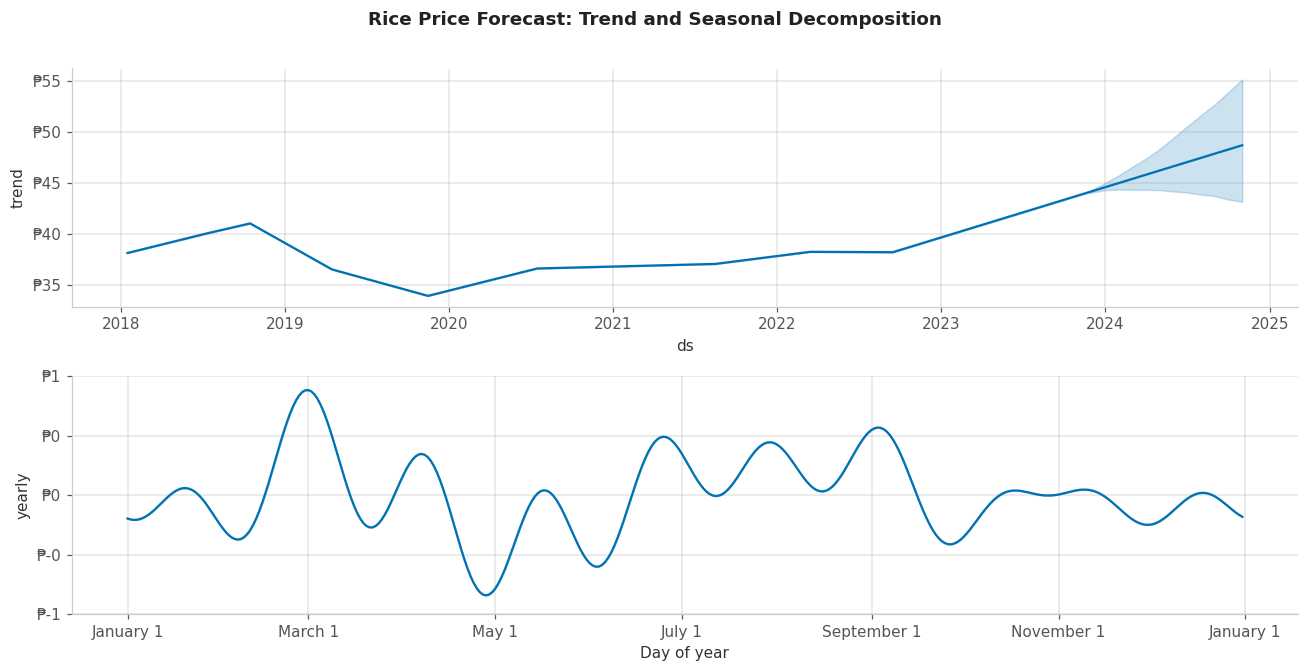

The seasonal component shows consistent price peaks in Q3 and Q4.
This aligns with typhoon season (July to October) when Luzon rice supply chains face disruption.


In [29]:
# Decompose the forecast into trend and seasonal components
fig = m_base.plot_components(fc_base)
fig.set_size_inches(12, 6)
for axis in fig.axes:
    axis.set_facecolor('white')
    axis.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))
fig.patch.set_facecolor('white')
fig.suptitle('Rice Price Forecast: Trend and Seasonal Decomposition',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('The seasonal component shows consistent price peaks in Q3 and Q4.')
print('This aligns with typhoon season (July to October) when Luzon rice supply chains face disruption.')


19:40:01 - cmdstanpy - INFO - Chain [1] start processing
19:40:02 - cmdstanpy - INFO - Chain [1] done processing
19:40:02 - cmdstanpy - INFO - Chain [1] start processing
19:40:02 - cmdstanpy - INFO - Chain [1] done processing
19:40:02 - cmdstanpy - INFO - Chain [1] start processing
19:40:02 - cmdstanpy - INFO - Chain [1] done processing


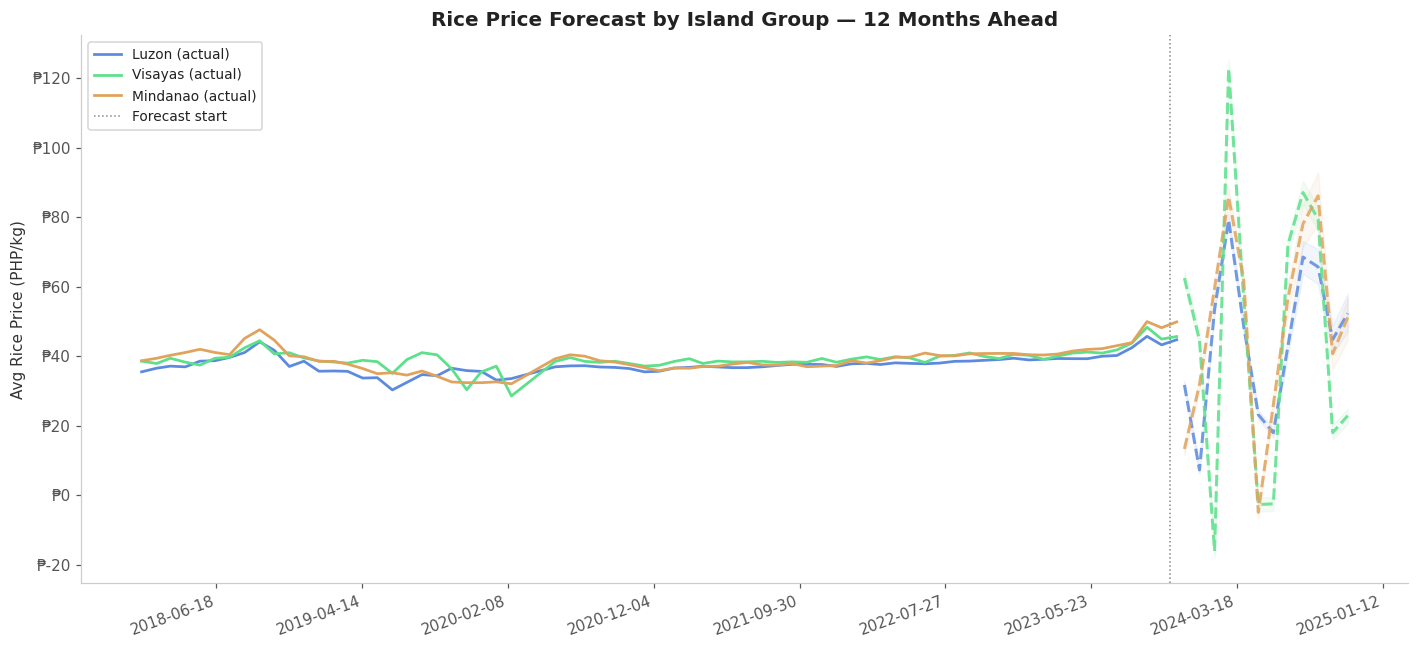

Island group forecast comparison:
  Luzon        Last: ₱44.79  Forecast avg: ₱44.70  (-0.2%)
  Visayas      Last: ₱45.71  Forecast avg: ₱45.44  (-0.6%)
  Mindanao     Last: ₱49.93  Forecast avg: ₱48.91  (-2.0%)


In [31]:
# Forecast by island group
fig, ax = plt.subplots(figsize=(13, 6))
island_colors = {'Luzon': '#5c8ae0', 'Visayas': '#5ce08a', 'Mindanao': '#e0a35c'}
island_results = {}

for island, color in island_colors.items():
    sub = (df[(df['commodity_name'] == 'Rice (regular, milled)') &
              (df['island_group'] == island)]
           .groupby('price_date')['price_php']
           .mean()
           .reset_index()
           .rename(columns={'price_date': 'ds', 'price_php': 'y'})
           .dropna()
           .sort_values('ds'))

    if len(sub) < 12:
        continue

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='multiplicative',
                changepoint_prior_scale=0.3, interval_width=0.90)
    m.fit(sub)
    future = m.make_future_dataframe(periods=12, freq='MS')
    fc = m.predict(future)
    future_only = fc[fc['ds'] > sub['ds'].max()]

    island_results[island] = {
        'last': sub['y'].iloc[-1],
        'forecast_avg': future_only['yhat'].mean()
    }

    ax.plot(sub['ds'], sub['y'], color=color, linewidth=1.8, label=f'{island} (actual)')
    ax.plot(future_only['ds'], future_only['yhat'],
            color=color, linewidth=2, linestyle='--', alpha=0.85)
    ax.fill_between(future_only['ds'],
                    future_only['yhat_lower'], future_only['yhat_upper'],
                    alpha=0.08, color=color)

ax.axvline(pd.Timestamp('2023-11-01'), color='#888', linewidth=1,
           linestyle=':', label='Forecast start')
ax.set_ylabel('Avg Rice Price (PHP/kg)')
ax.set_title('Rice Price Forecast by Island Group — 12 Months Ahead',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('Island group forecast comparison:')
for island, res in island_results.items():
    chg = (res['forecast_avg'] / res['last'] - 1) * 100
    print(f'  {island:<12} Last: ₱{res["last"]:.2f}  Forecast avg: ₱{res["forecast_avg"]:.2f}  ({chg:+.1f}%)')


## 5. Summary Statistics

In [33]:
print('=' * 60)
print('  PHILIPPINE FOOD PRICE ANALYTICS — KEY FINDINGS')
print('=' * 60)

y2018 = df[df['price_year'] == 2018]['price_php'].mean()
y2023 = df[df['price_year'] == 2023]['price_php'].mean()
print(f'\n1. National avg food price change (2018 to 2023):')
print(f'   2018: ₱{y2018:.2f}/kg  to  2023: ₱{y2023:.2f}/kg  ({(y2023/y2018-1)*100:+.1f}%)')

bsp_2018 = df[df['price_year'] == 2018]['monthly_bsp_rate'].mean()
bsp_2023 = df[df['price_year'] == 2023]['monthly_bsp_rate'].mean()
if not np.isnan(bsp_2018):
    print(f'\n2. Peso depreciation (2018 to 2023):')
    print(f'   2018 avg rate: ₱{bsp_2018:.2f}/USD  to  2023: ₱{bsp_2023:.2f}/USD  ({(bsp_2023/bsp_2018-1)*100:+.1f}%)')

exp_region = df.groupby('region_name')['price_php'].mean().idxmax()
exp_price  = df.groupby('region_name')['price_php'].mean().max()
chp_region = df.groupby('region_name')['price_php'].mean().idxmin()
chp_price  = df.groupby('region_name')['price_php'].mean().min()
print(f'\n3. Most expensive region : {exp_region} at ₱{exp_price:.2f}/kg')
print(f'4. Least expensive region: {chp_region} at ₱{chp_price:.2f}/kg')

gap_region = gap_df.groupby('region_name')['inflation_gap'].mean().idxmax()
gap_val    = gap_df.groupby('region_name')['inflation_gap'].mean().max()
print(f'\n5. Largest inflation gap : {gap_region} at +₱{gap_val:.2f} above CPI')

volatility = df.groupby('commodity_name')['price_php'].std().sort_values(ascending=False)
print(f'\n6. Most volatile commodity: {volatility.idxmax()} (std = ₱{volatility.max():.2f})')

print('\n' + '=' * 60)


  PHILIPPINE FOOD PRICE ANALYTICS — KEY FINDINGS

1. National avg food price change (2018 to 2023):
   2018: ₱85.18/kg  to  2023: ₱139.30/kg  (+63.5%)

2. Peso depreciation (2018 to 2023):
   2018 avg rate: ₱52.64/USD  to  2023: ₱55.63/USD  (+5.7%)

3. Most expensive region : National Capital Region at ₱161.16/kg
4. Least expensive region: Bangsamoro Autonomous Region at ₱96.59/kg

5. Largest inflation gap : National Capital Region at +₱47.61 above CPI

6. Most volatile commodity: Shrimp (tiger) (std = ₱157.27)



## 6. Conclusions

### The Inflation Gap

The clearest finding in this analysis is the persistent divergence between WFP market prices and official PSA CPI figures, most pronounced in the National Capital Region. The gap is not just a statistical artifact. It reflects a structural difference between what the CPI basket measures and what wet-market shoppers actually pay.

NCR shows the largest positive gap, meaning market prices there consistently run above what the CPI index implies. This matters for policy because social protection programs calibrated to official inflation may be systematically underestimating the pressure urban households face at the market level.

BARMM and Northern Mindanao show negative gaps, meaning actual market prices run below the CPI index in those regions. These are major agricultural production zones, and their supply advantages translate directly to lower food costs for local households. This geographic difference is often invisible in national-level statistics.

The gap widened after 2020 and has not fully recovered. That post-COVID persistence, especially in NCR and Central Luzon, is the pattern most worth continuing to monitor.

### The BSP Exchange Rate

The lag analysis in Part 1 confirmed that peso depreciation is a statistically significant leading indicator of food price increases, with the strongest signal at a one to two month lag. The commodity category breakdown shows this effect is not uniform. Categories with higher import content are more sensitive to exchange rate movements than locally produced staples.

For the rice forecast, including the BSP rate as an external regressor changes the projected price meaningfully when the peso is on a depreciating trend. When the exchange rate is stable, the two models converge. This conditional usefulness is actually an interesting result. It tells us the exchange rate adds signal specifically during currency stress periods, which are also the times when food affordability pressure is most acute.

### Rice Price Trajectory

The Prophet model projects continued upward pressure on rice prices through 2024, with Luzon showing the steepest increase. The seasonal decomposition confirms reliable price peaks in Q3 and Q4 tied to typhoon season. This is consistent with observed market behavior and with what happened after the 2023 India rice export restrictions tightened global supply.

The island-group forecast divergence is worth noting. Mindanao starts from a lower price base and shows more modest projected increases. National-average rice forecasts mask very different regional realities, and responses calibrated to the national average will over and under-shoot simultaneously.

---